# NYC Airbnb 




In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler   

## 1) Cargar datos

In [73]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [74]:
id_unico=pd.DataFrame(df["id"].value_counts())

In [75]:
id_unico.sort_values("count",ascending=True)

,count
id,
2539,1
2595,1
3647,1
3831,1
5022,1
...,...
36484665,1
36485057,1
36485431,1


In [76]:
len(df["id"].unique())

48895

## 2) Exploración rápida

In [77]:
print("Shape:", df.shape)


Shape: (48895, 16)


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [79]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [80]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [81]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [82]:
df.isnull().sum().sort_values(ascending=False).head(10)

last_review            10052
reviews_per_month      10052
host_name                 21
name                      16
neighbourhood_group        0
neighbourhood              0
id                         0
host_id                    0
longitude                  0
latitude                   0
dtype: int64

## 3) Limpieza básica
- Quitamos columnas poco útiles para un baseline.
- Quitamos precios en 0.


In [83]:
df = df.drop(["id", "name", "host_name", "last_review"], axis=1)
df

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [84]:
df = df[df["price"] > 0]
#df.shape

In [85]:
df["price"].describe()

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

## 4) Visualizaciones clave
### 4.1 Distribución de precios 

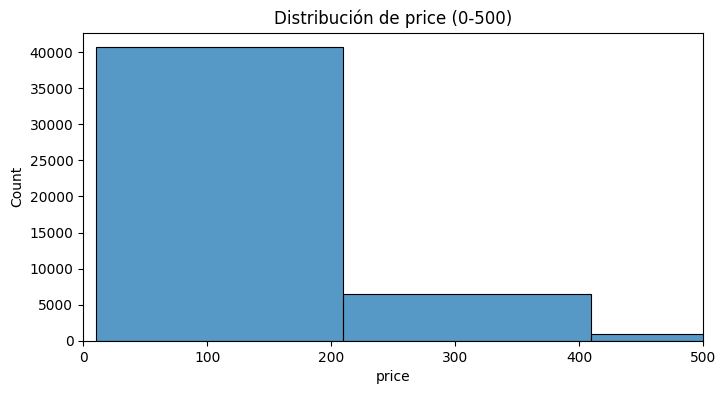

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=50)
plt.xlim(0, 500)
plt.title("Distribución de price (0-500)")
plt.show()

### 4.2 Precio por tipo de habitación

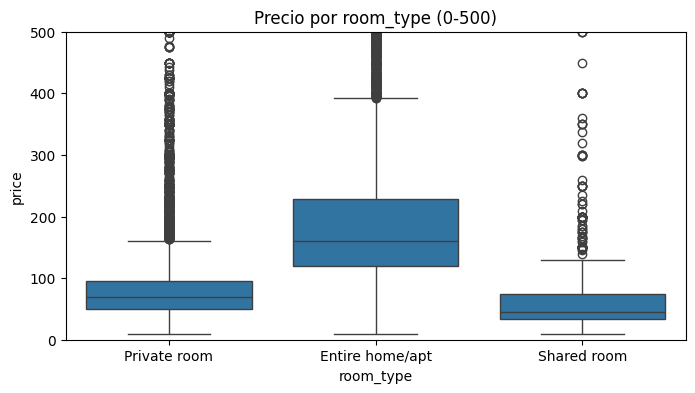

In [87]:
plt.figure(figsize=(8,4))
sns.boxplot(x="room_type", y="price", data=df)
plt.ylim(0, 500)
plt.title("Precio por room_type (0-500)")
plt.show()

### 4.3 Precio por distrito (neighbourhood_group)

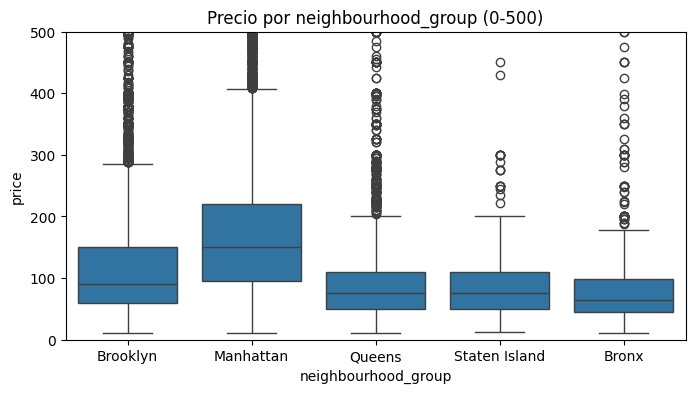

In [88]:
plt.figure(figsize=(8,4))
sns.boxplot(x="neighbourhood_group", y="price", data=df)
plt.ylim(0, 500)
plt.title("Precio por neighbourhood_group (0-500)")
plt.show()

## 5) Correlación numérica simple

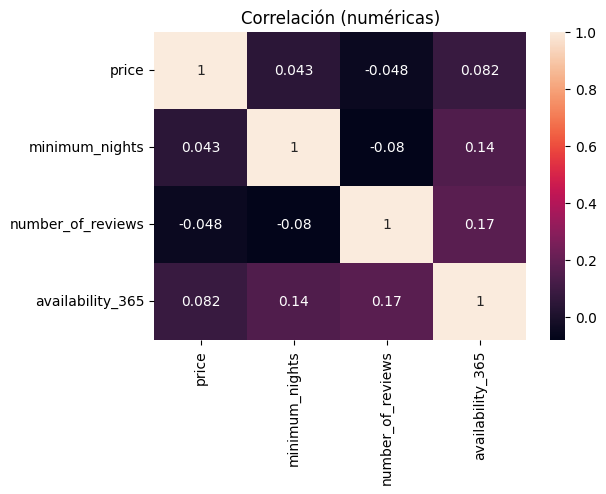

In [89]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["price","minimum_nights","number_of_reviews","availability_365"]].corr(), annot=True)
plt.title("Correlación (numéricas)")
plt.show()

## 6) Ingeniería de Características - Outliers
En lugar de IQR manual, usamos cortes prácticos (baseline):
- price < 500
- minimum_nights < 30


In [90]:
df = df[df["price"] < 500]
df = df[df["minimum_nights"] < 30]
df.shape

(43274, 12)

## 7) Preparación para modelado
### 7.1 One-hot encoding para categóricas


In [91]:
#df_model = pd.get_dummies(df).astype(int)
df_model = pd.get_dummies(df)
df_model.head()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2787,40.64749,-73.97237,149,1,9,0.21,6,365,False,...,False,False,False,False,False,False,False,False,True,False
1,2845,40.75362,-73.98377,225,1,45,0.38,2,355,False,...,False,False,False,False,False,False,False,True,False,False
2,4632,40.80902,-73.94190,150,3,0,NaN,1,365,False,...,False,False,False,False,False,False,False,False,True,False
3,4869,40.68514,-73.95976,89,1,270,4.64,1,194,False,...,False,False,False,False,False,False,False,True,False,False
4,7192,40.79851,-73.94399,80,10,9,0.10,1,0,False,...,False,False,False,False,False,False,False,True,False,False


### 7.2 Escalado (solo numéricas)

In [92]:
scaler = MinMaxScaler()
num_cols = ["minimum_nights", "number_of_reviews", "availability_365"]
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])
df_model[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
minimum_nights,43274.0,0.089387,0.151353,0.0,0.00000,0.035714,0.107143,1.0
number_of_reviews,43274.0,0.039957,0.073502,0.0,0.00159,0.009539,0.041335,1.0
availability_365,43274.0,0.273024,0.344263,0.0,0.00000,0.076712,0.498630,1.0


In [93]:
df_model

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2787,40.64749,-73.97237,149,0.000000,0.014308,0.21,6,1.000000,False,...,False,False,False,False,False,False,False,False,True,False
1,2845,40.75362,-73.98377,225,0.000000,0.071542,0.38,2,0.972603,False,...,False,False,False,False,False,False,False,True,False,False
2,4632,40.80902,-73.94190,150,0.071429,0.000000,NaN,1,1.000000,False,...,False,False,False,False,False,False,False,False,True,False
3,4869,40.68514,-73.95976,89,0.000000,0.429253,4.64,1,0.531507,False,...,False,False,False,False,False,False,False,True,False,False
4,7192,40.79851,-73.94399,80,0.321429,0.014308,0.10,1,0.000000,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,8232441,40.67853,-73.94995,70,0.035714,0.000000,NaN,2,0.024658,False,...,False,False,False,False,False,False,False,False,True,False
48891,6570630,40.70184,-73.93317,40,0.107143,0.000000,NaN,2,0.098630,False,...,False,False,False,False,False,False,False,False,True,False
48892,23492952,40.81475,-73.94867,115,0.321429,0.000000,NaN,1,0.073973,False,...,False,False,False,False,False,False,False,True,False,False
48893,30985759,40.75751,-73.99112,55,0.000000,0.000000,NaN,6,0.005479,False,...,False,False,False,False,False,False,False,False,False,True


## 8) Selección de variables 
Como `price` es continua, una forma rápida es ordenar la correlación con `price`.


In [94]:
corr = df_model.corr(numeric_only=True)["price"].sort_values(ascending=False)
corr.head(20)

price                               1.000000
room_type_Entire home/apt           0.566269
neighbourhood_group_Manhattan       0.301834
neighbourhood_Midtown               0.168533
neighbourhood_Chelsea               0.117387
neighbourhood_Hell's Kitchen        0.115605
neighbourhood_West Village          0.115562
neighbourhood_Financial District    0.110287
calculated_host_listings_count      0.107282
neighbourhood_East Village          0.083762
neighbourhood_Greenwich Village     0.072639
neighbourhood_Upper West Side       0.070593
availability_365                    0.068900
neighbourhood_Upper East Side       0.066939
neighbourhood_SoHo                  0.066013
neighbourhood_Tribeca               0.064620
neighbourhood_Murray Hill           0.063939
latitude                            0.058757
neighbourhood_NoHo                  0.052363
neighbourhood_Nolita                0.049663
Name: price, dtype: float64

### Guardar dataset limpio

In [95]:
df_model.to_csv("nyc_airbnb_clean_simple.csv", index=False)
print("Guardado: nyc_airbnb_clean_simple.csv")

Guardado: nyc_airbnb_clean_simple.csv
